<a href="https://colab.research.google.com/github/snehakodavanti-droid5/AIML---Training/blob/main/AIML_Module_5_Lab_1_Linear_Regression%2C_MSE_and_Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression Lab 1: Linear Regression, MSE and Polynomial Regression

Linear regression is a technique that is used to model a linear relationship between some data $x$ and its corresponding output $y$. When there are multiple inputs ($x_1, x_2, .. , x_n$), it is referred to as **Mutliple Linear Regression**.

Essentially, we model the relationship as $y = mx + c$. Linear regression attempts to find the $m$ and $c$ values.

To understand how linear regression works, let's first look at an example.

In [1]:
import numpy as np
from sklearn import linear_model,metrics
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
# from sklearn.datasets import load_boston
from sklearn.datasets import fetch_california_housing
import pandas as pd
import seaborn as sns
import math

import warnings
warnings.filterwarnings('ignore')

from matplotlib import pyplot as plt
plt.style.use('seaborn-v0_8')
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 12, 8
np.random.seed(42)

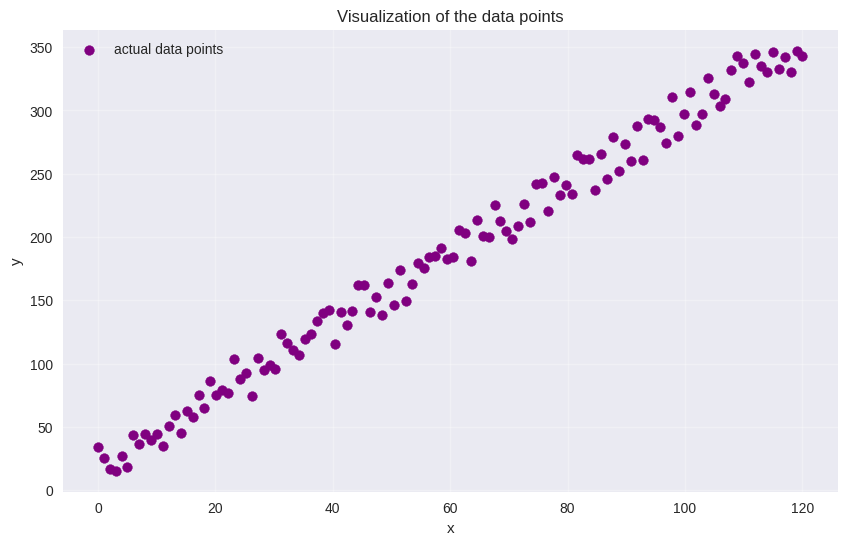

In [2]:
# generating random data points and adding noise

np.random.seed(25)

x = np.linspace(0,120,120).reshape((-1,1))
y = (np.random.rand(120)*40).astype(int).reshape((-1,1)) + 2.8*x

plt.figure(figsize=(10,6))

plt.title("Visualization of the data points")
plt.scatter(x,y,color="purple")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(["actual data points"])
plt.grid(True, alpha=0.3)
plt.show()


## Brute-force solution

Let's first think of a naive appraoch to this problem. Since we want to find the values of $m$ and $c$, we can do a search in the space of possible $m$ and $c$ values, and pick the line with the least average distance from the actual data.

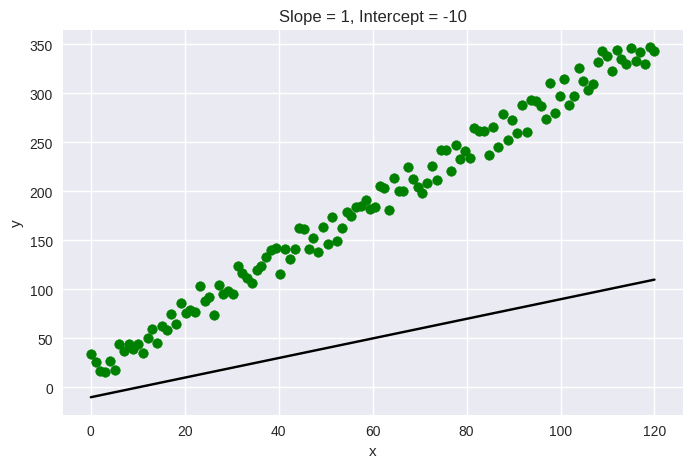

Average distance: 136.88333333333333



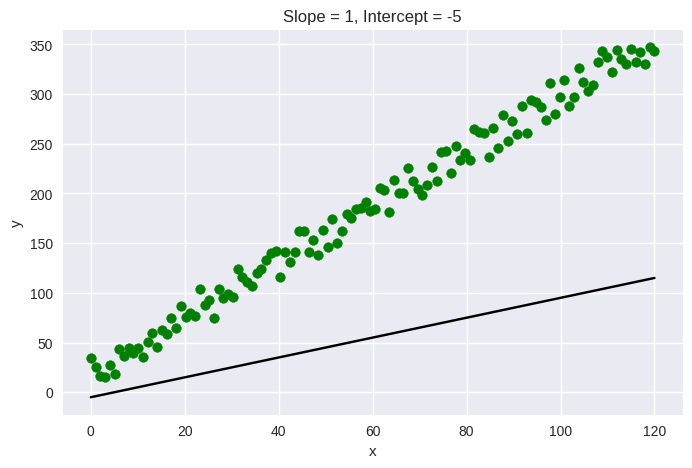

Average distance: 131.8833333333333



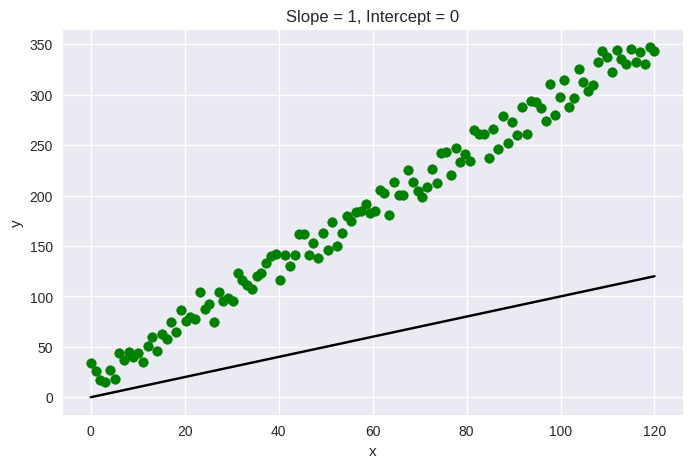

Average distance: 126.8833333333333



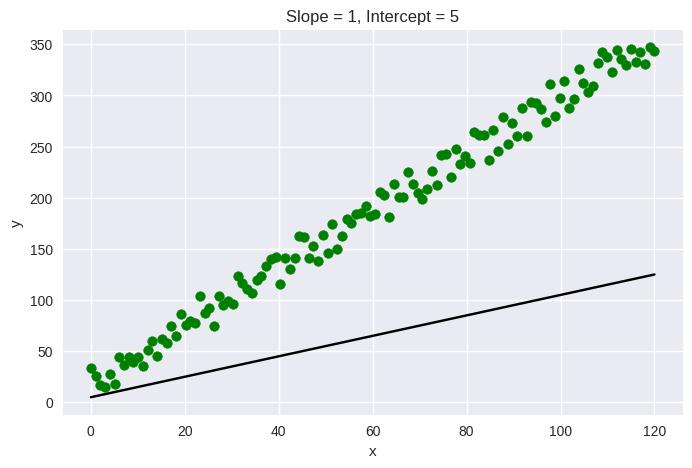

Average distance: 121.8833333333333



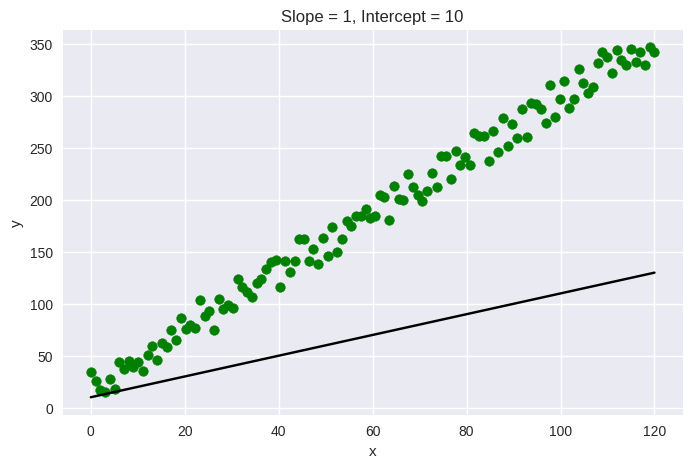

Average distance: 116.8833333333333



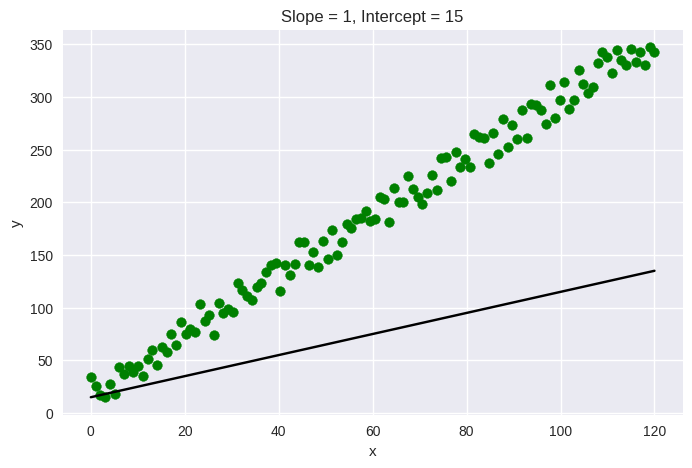

Average distance: 111.96414565826329



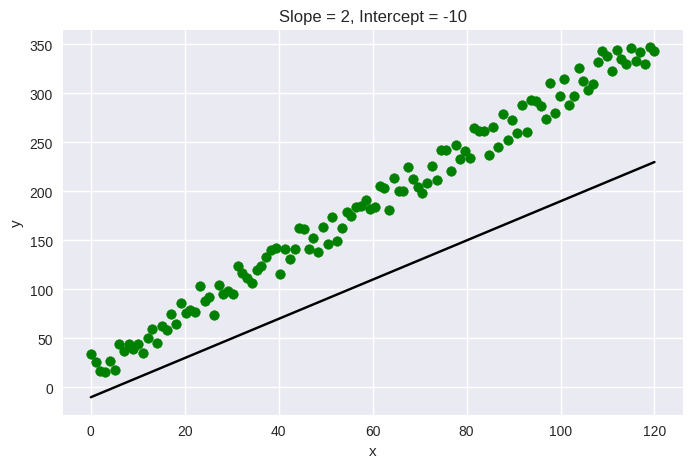

Average distance: 76.88333333333334



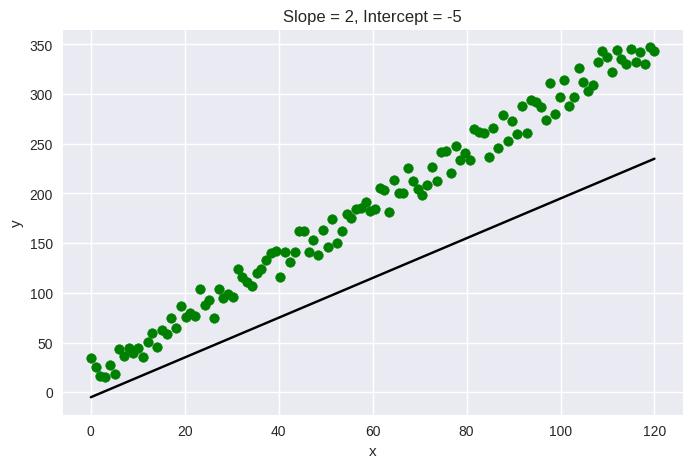

Average distance: 71.88333333333331



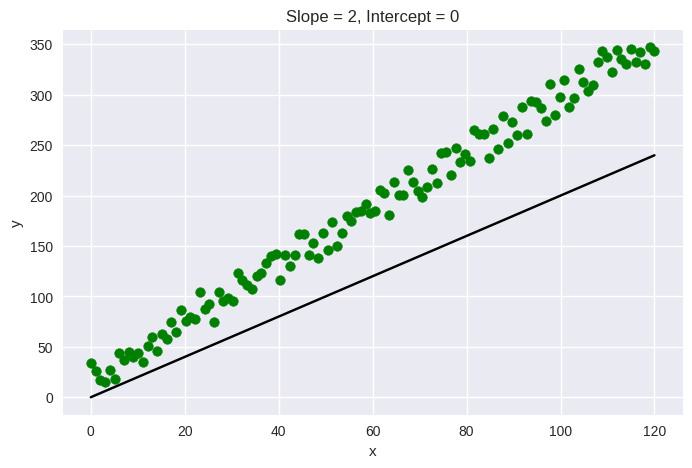

Average distance: 66.88333333333331



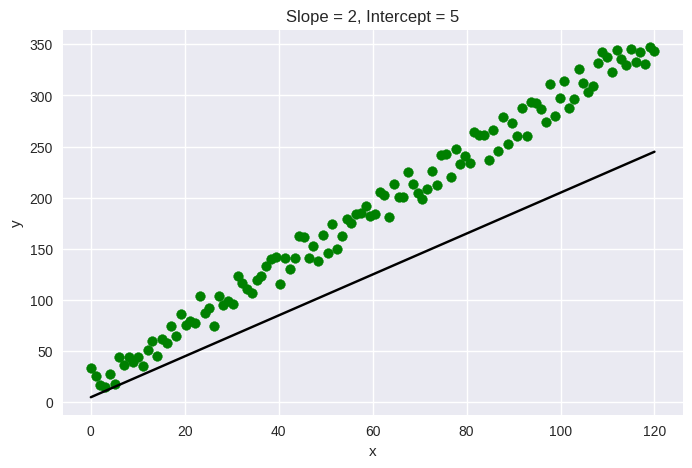

Average distance: 61.88333333333332



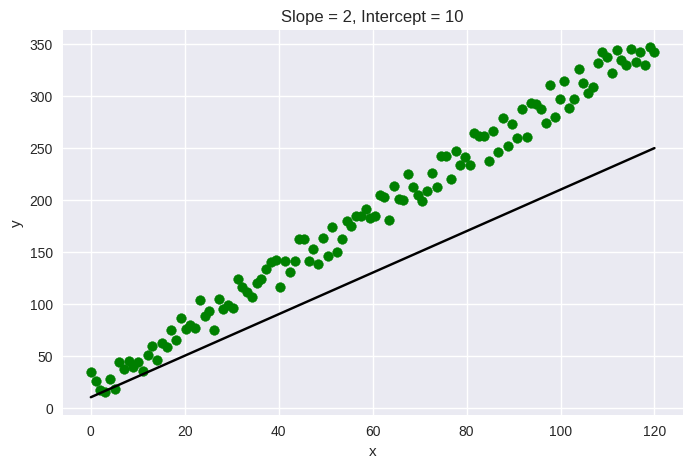

Average distance: 56.925770308123234



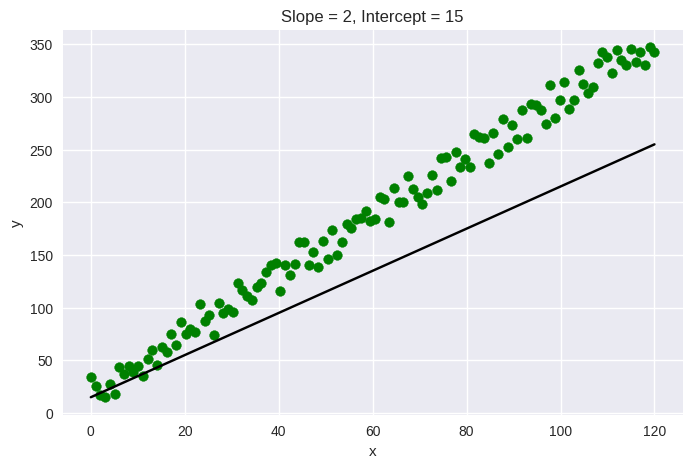

Average distance: 52.16764705882351



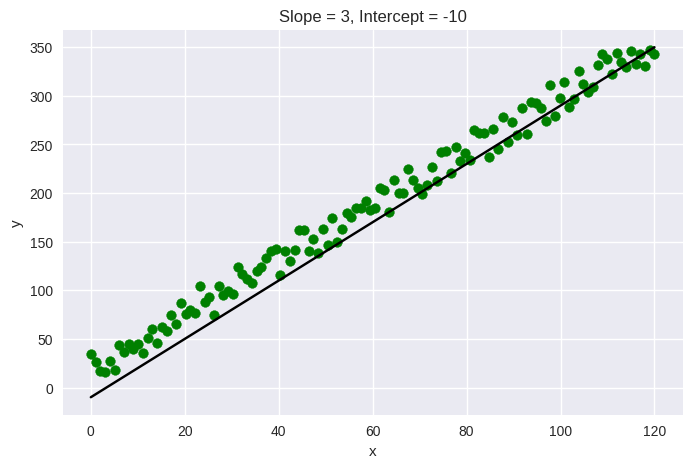

Average distance: 18.27072829131652



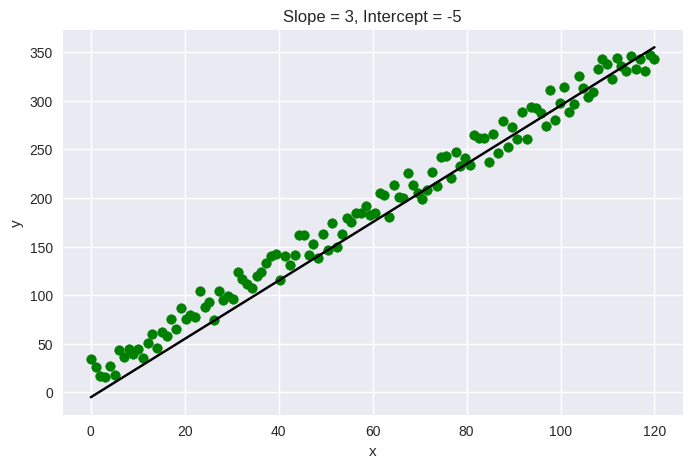

Average distance: 15.182773109243696



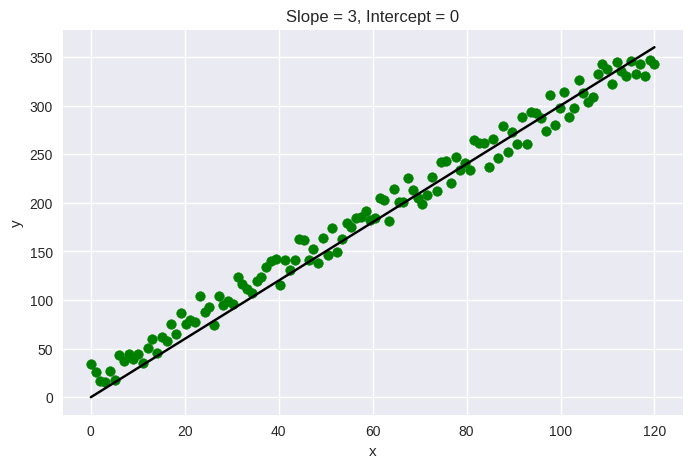

Average distance: 12.82577030812325



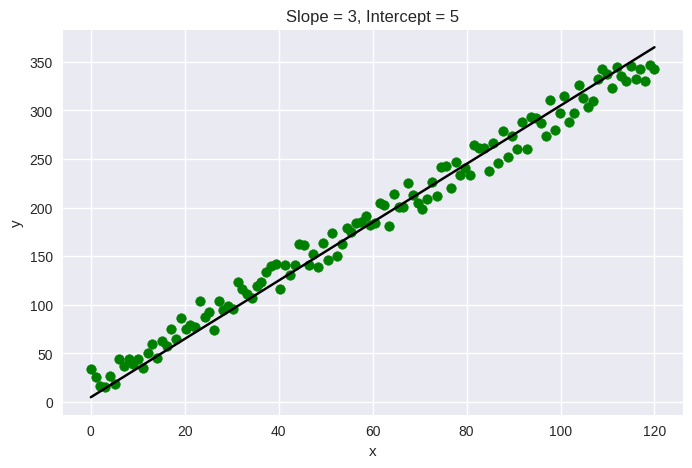

Average distance: 11.27058823529412



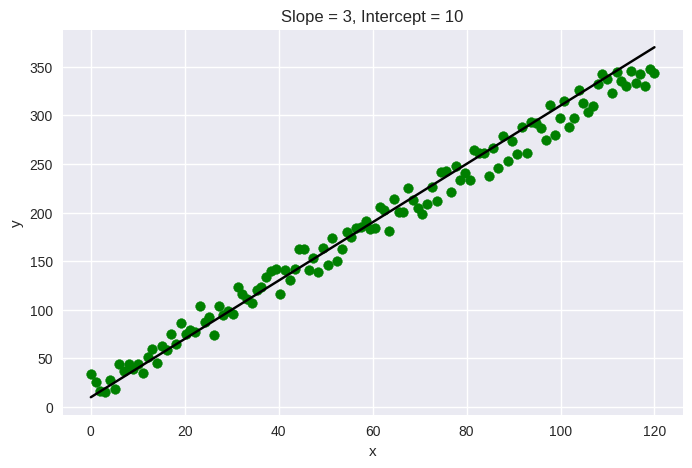

Average distance: 10.724089635854344



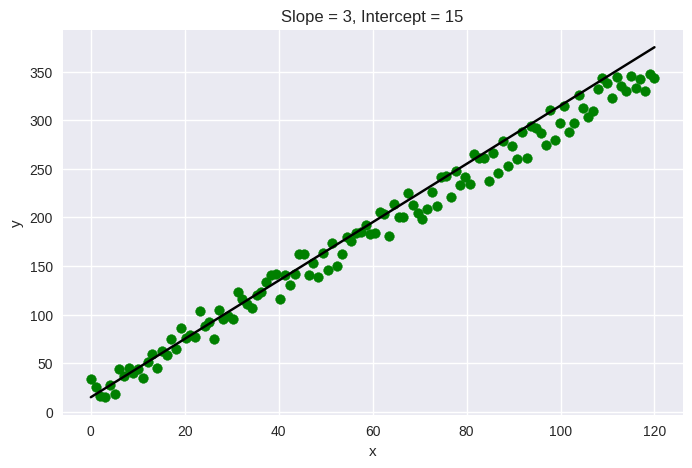

Average distance: 11.69117647058824



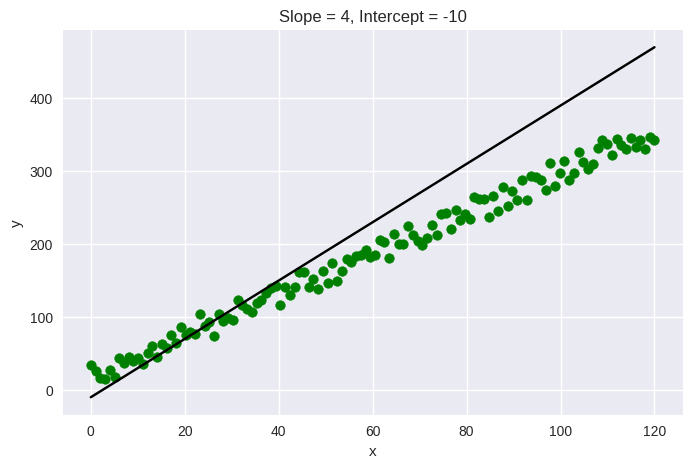

Average distance: 49.21834733893558



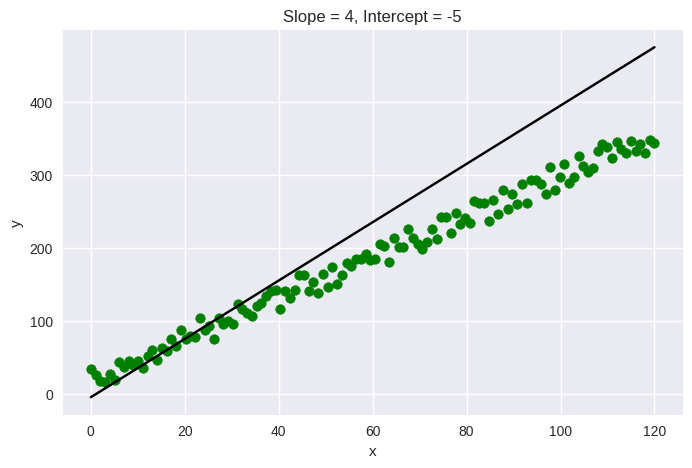

Average distance: 52.32436974789916



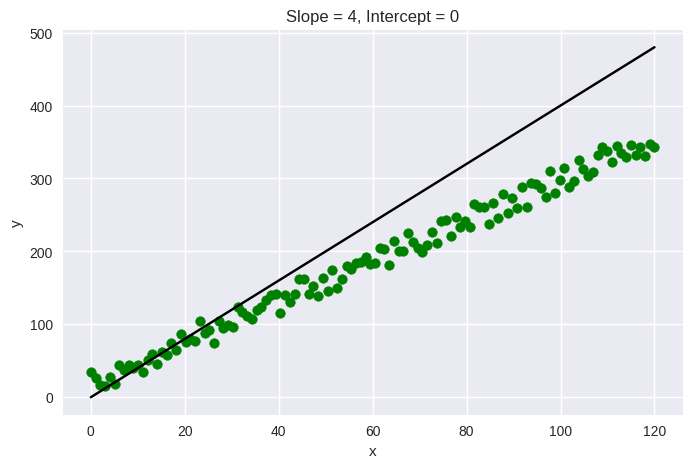

Average distance: 55.87829131652662



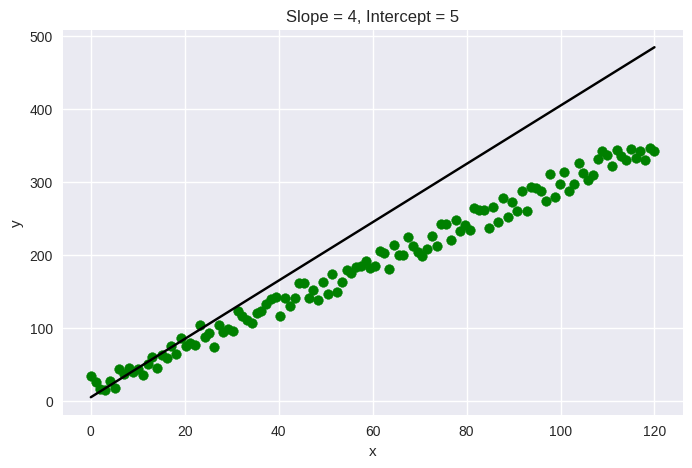

Average distance: 59.716526610644266



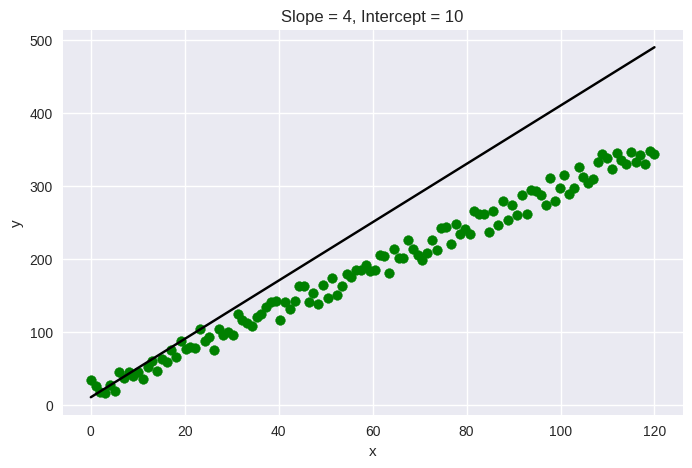

Average distance: 63.953081232493005



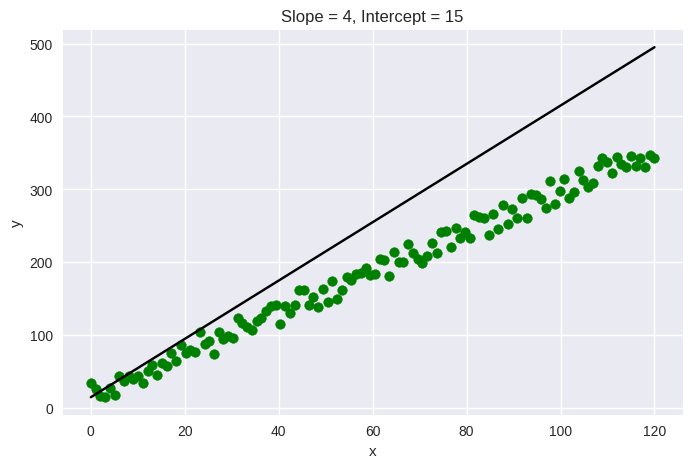

Average distance: 68.62549019607845



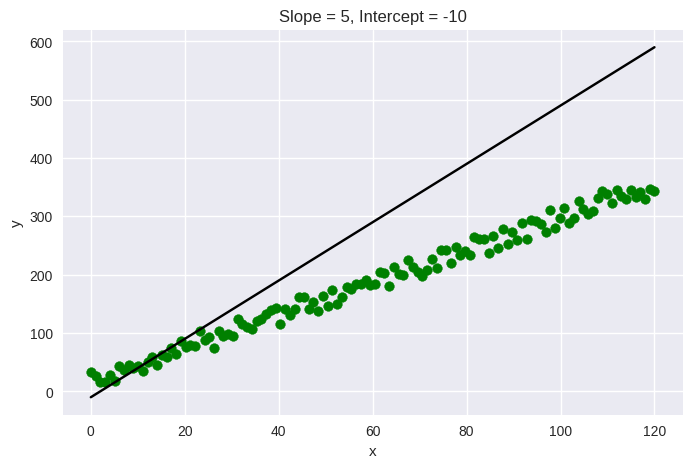

Average distance: 106.18949579831933



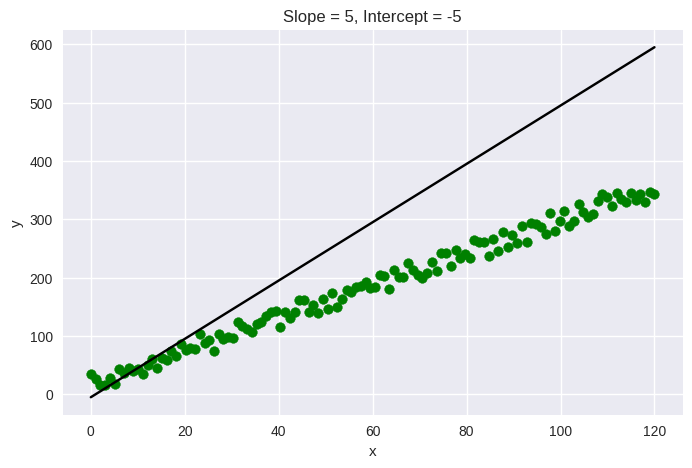

Average distance: 110.25378151260504



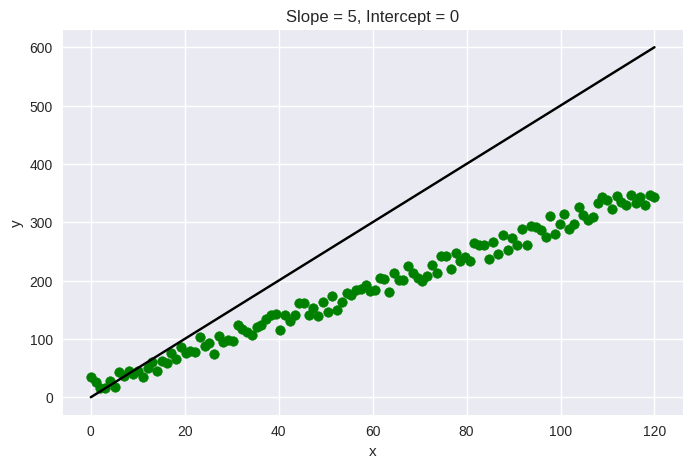

Average distance: 114.58711484593839



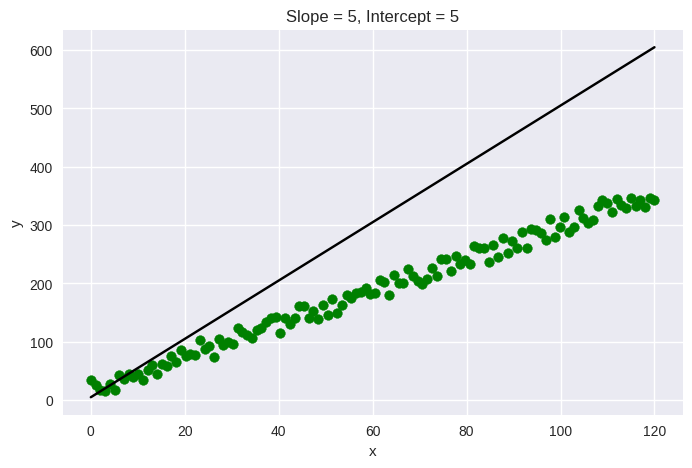

Average distance: 119.06932773109244



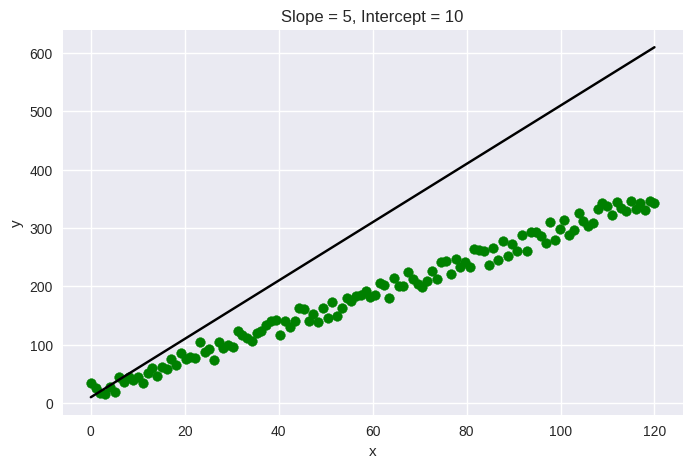

Average distance: 123.75784313725491



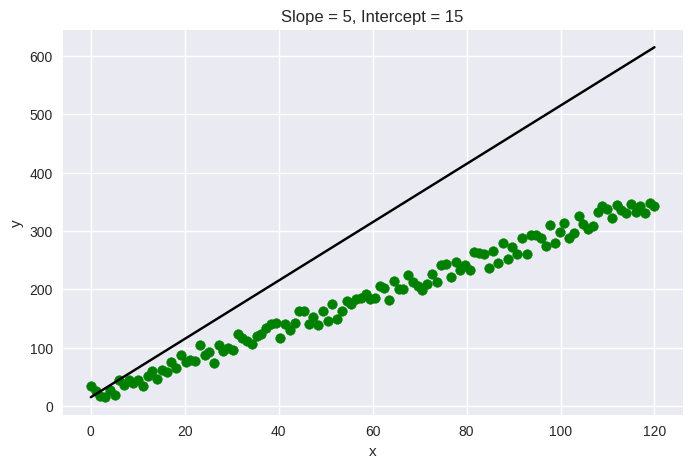

Average distance: 128.5296918767507



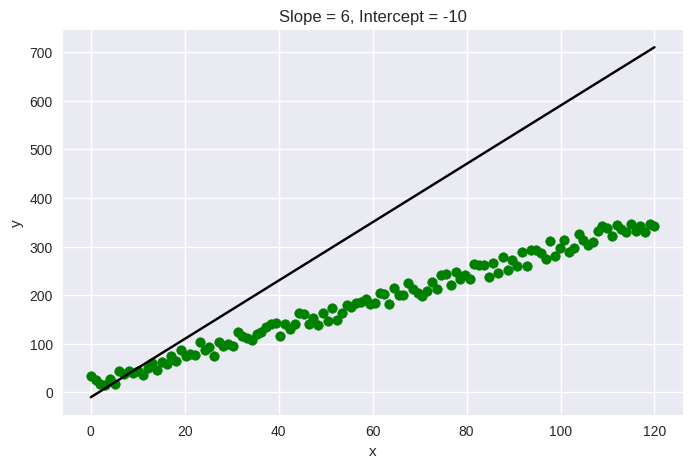

Average distance: 165.39943977591034



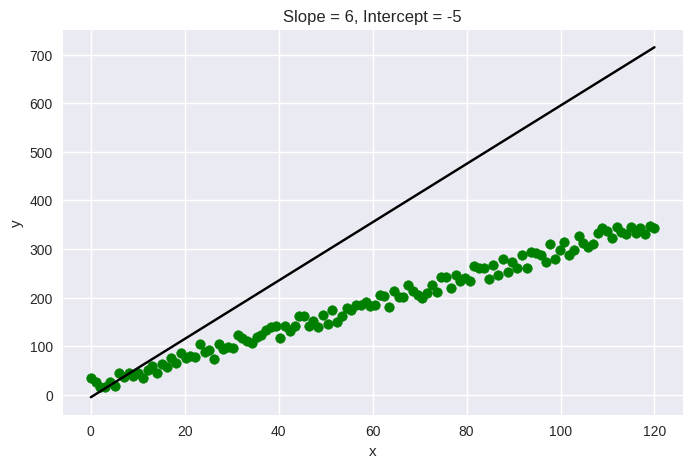

Average distance: 169.74257703081233



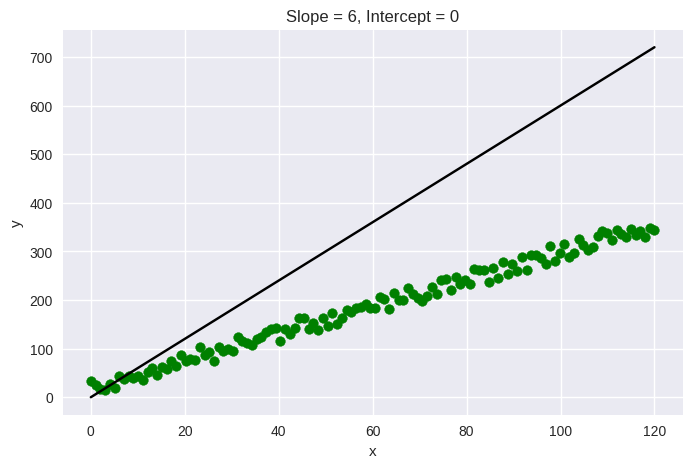

Average distance: 174.26750700280115



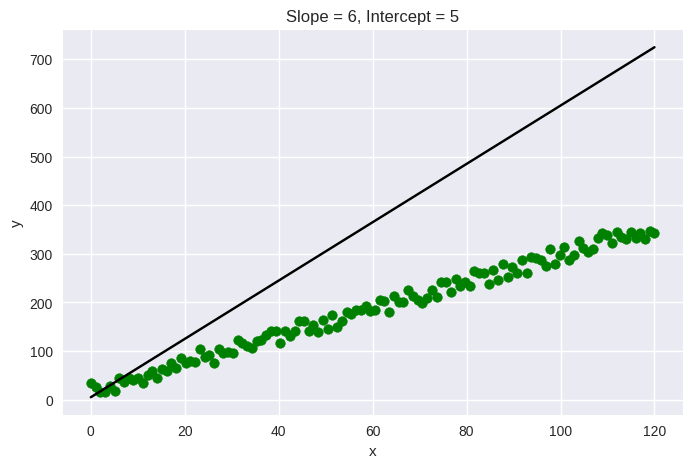

Average distance: 178.89019607843142



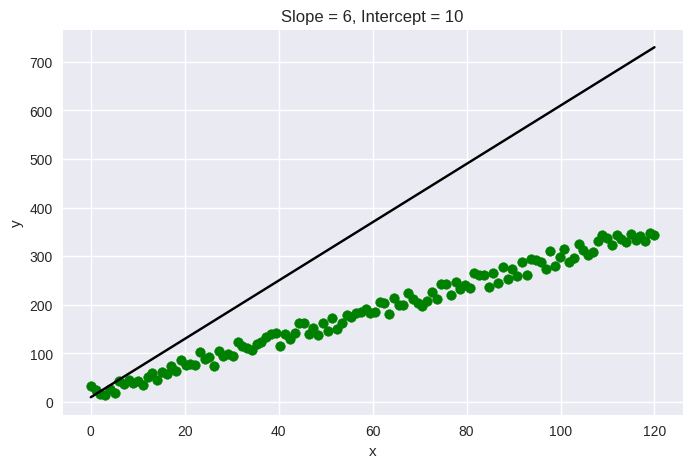

Average distance: 183.6795518207283



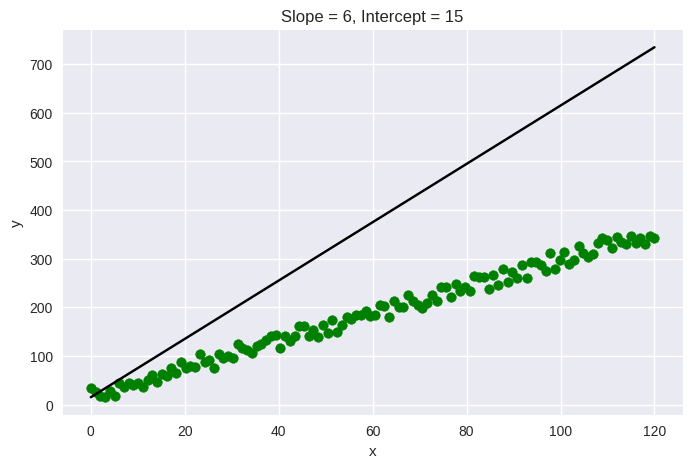

Average distance: 188.51288515406165



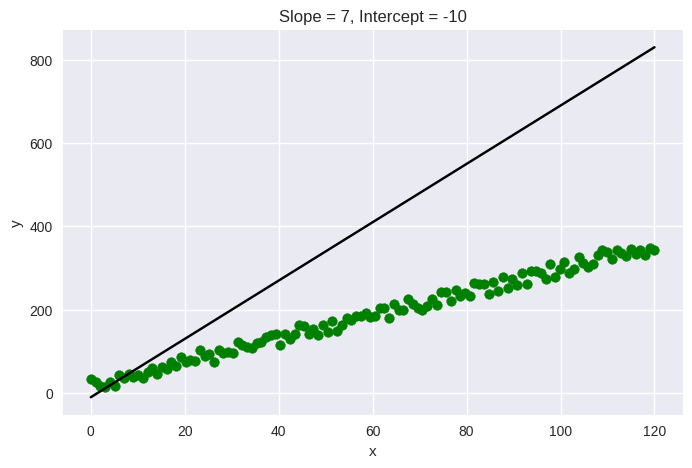

Average distance: 224.95392156862744



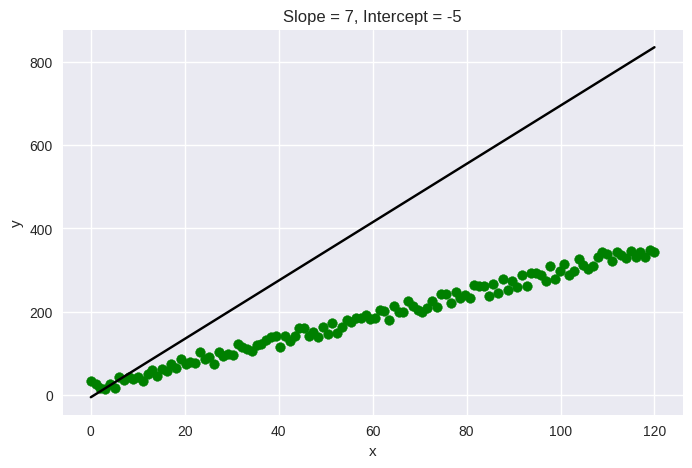

Average distance: 229.46568627450978



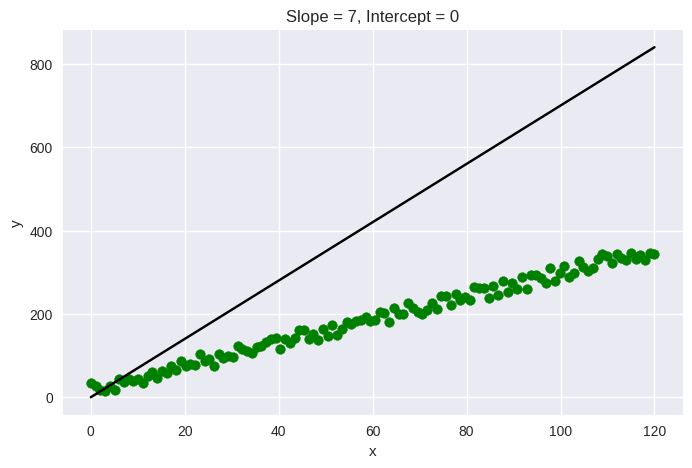

Average distance: 234.06470588235294



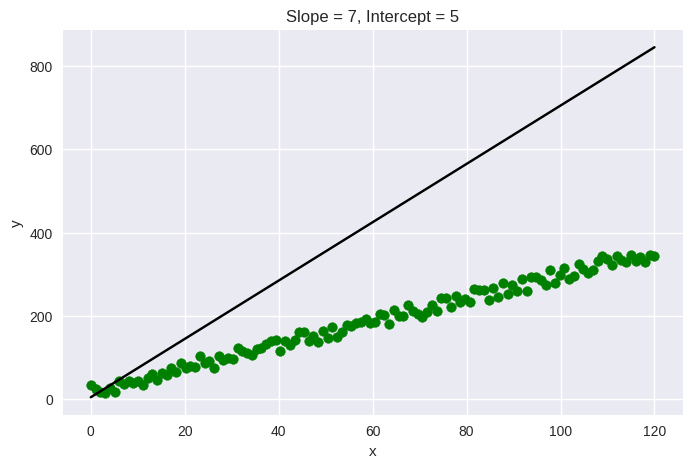

Average distance: 238.8294117647059



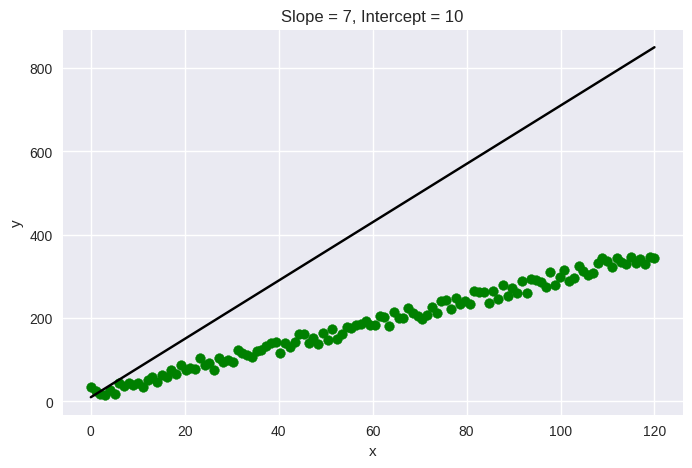

Average distance: 243.6627450980392



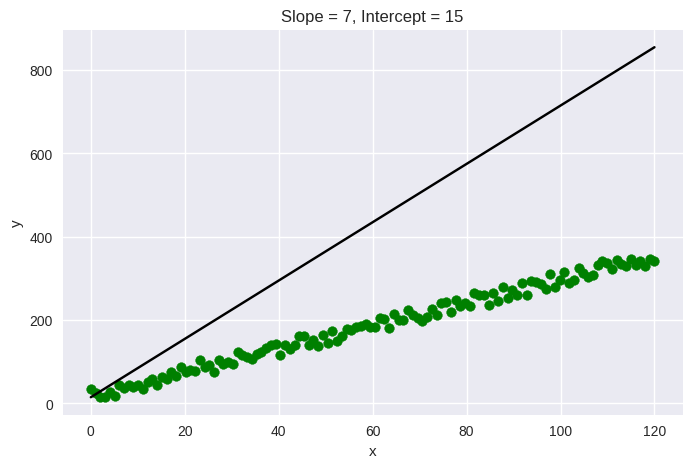

Average distance: 248.49607843137255



In [3]:
# brute-force solution of rotating line and searching through space of lines for best fit

for m in range(1,8):
  for c in range(-10,16,5):
    py = (m*x + c).reshape((-1,1))
    error = np.mean(np.abs(y - py))
    plt.figure(figsize=(8,5))

    plt.plot(x,py,color="black")
    plt.scatter(x,y,color="green")
    plt.title(f"Slope = {m}, Intercept = {c}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

    print("Average distance: {}\n".format(np.mean(np.sqrt((y-py)**2))))

Looking at the graphs, the best solution from the brute-force method doesn't seem too bad. In fact, an average distance of 6 isn't bad at all! But, there's one obvious drawback to this approach: it's very inefficient. The search space for the given data may be low, but that is not always the case. Additionally, this approach doesn't guarantee the best possible values. Unless we make the $\delta m$ and $\delta c$ very infinitesimally small (which would make this solution extremely slow), the "best" value obtained may not even be close to the best possible value. So, how do we fix this issue? We turn to a technique called **linear regression**.   

In [9]:
def lin_regression(x,y):

  # learning the coefficient and intercept

  x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

  m1 = linear_model.LinearRegression()
  m1.fit(x_train,y_train)

  print("The coefficient is: {} and the intercept is: {}\n".format(m1.coef_[0][0],m1.intercept_[0]))

  y_pred = m1.predict(x_test)
  metrics.mean_squared_error(y_pred,y_test)

  # plotting data and predictions

  plt.figure(figsize=(10,6))
  plt.scatter(x, y, color="green")
  x_line = np.sort(x_test, axis=0)
  y_line = m1.predict(x_line)
  plt.plot(x_line, y_line, color="black", linewidth=2)
  plt.title("Linear Regression Fit")
  plt.xlabel("x")
  plt.ylabel("y")
  plt.legend(["Regression Line", "Actual Data"])
  plt.grid(True, alpha=0.3)
  plt.show()
  print("The RMSE for linear regression is: {}".format(math.sqrt(metrics.mean_squared_error(y_pred,y_test))))

The coefficient is: 2.764497252868058 and the intercept is: 20.741410967208424



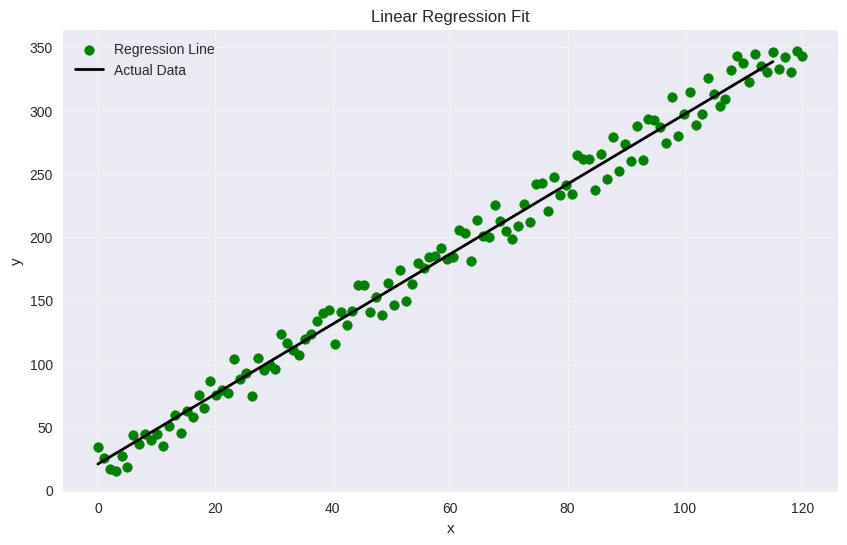

The RMSE for linear regression is: 11.773082310485549


In [10]:
lin_regression(x,y)

From the above graph, we can see that the predicted line is pretty close to the actual linear relationship between $x$ and $y$. But, how does linear regression actually work ?

The main goal of linear regression (or regression in general) is to minimize the **error** of the model. Typically, **mean squared error (MSE)** is used as the error term.

Suppose we have some data $x$ and outputs $y$. Now, we obtain some predictions $y_p$ for $x$ using our linear regression model.
The mean squared error is then defined as:

$E = \frac{1}{m} \sum_{i=1}^n (y-y_p)^2$

intuitively, we can think of it as a distance between the actual value and the predicted value. By giving our regression model "feedback" on how far it is, it eventually learns the correct relationship between $x$ and $y$. So, the model tries to learn the values of $m$ and $c$ for which the equation $y=mx +c$ has the least error.

Generally, we look at the Root Mean Squared Error during analysis.

## The need for polynomial regression

The drawback with linear regression is that it tries to model a linear relationship between $x$ and $y$. More often than not, data does cannot be modelled by a linear equation. Let's look at an example of how linear regression falls short.

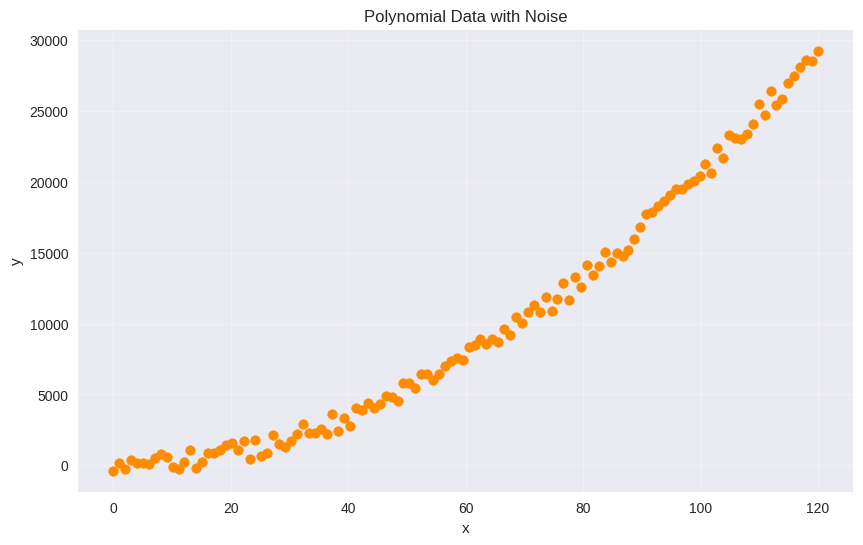

In [11]:
# simple polynomial with noise
np.random.seed(30)
y2 = (np.random.randint(-800, 800, x.shape)).reshape((-1,1)) + 2 * x**2 + 5 * x
plt.figure(figsize=(10,6))

plt.scatter(x,y2,color="darkorange")
plt.title("Polynomial Data with Noise")
plt.xlabel("x")
plt.ylabel("y")

plt.grid(True, alpha=0.3)
plt.show()

In [12]:
# POLYNOMIAL REGRESSION

def poly_regression(x, y, deg):
    x = x.reshape((-1,1))
    y = y.reshape((-1,1))
    poly = PolynomialFeatures(degree=deg)
    x_= poly.fit_transform(x)
    m1 = linear_model.LinearRegression()
    m1.fit(x_, y)
    y_pred = m1.predict(x_)
    rmse = np.sqrt(metrics.mean_squared_error(y, y_pred))
    plt.figure(figsize=(10,6))
    plt.scatter(x, y, color="green")
    sorted_idx = np.argsort(x.flatten())
    plt.plot(x[sorted_idx],y_pred[sorted_idx],color="black",linewidth=2)
    plt.title(f"Polynomial Regression (Degree = {deg})")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend(["Predicted Polynomial", "Actual Data"])
    plt.grid(True, alpha=0.3)
    plt.show()
    print(f"Polynomial Degree: {deg}")
    print(f"RMSE: {rmse:.3f}")

The coefficient is: 246.6731153398976 and the intercept is: -4748.082034665073



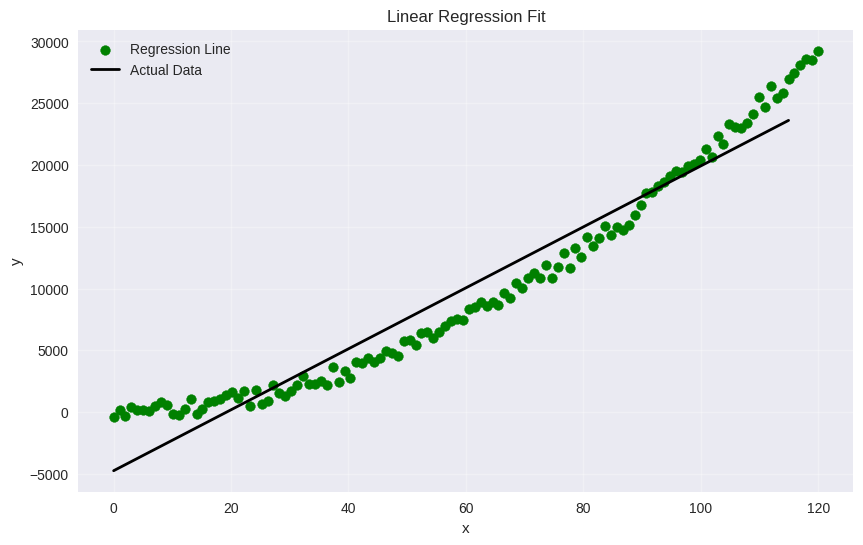

The RMSE for linear regression is: 2134.7699567318773


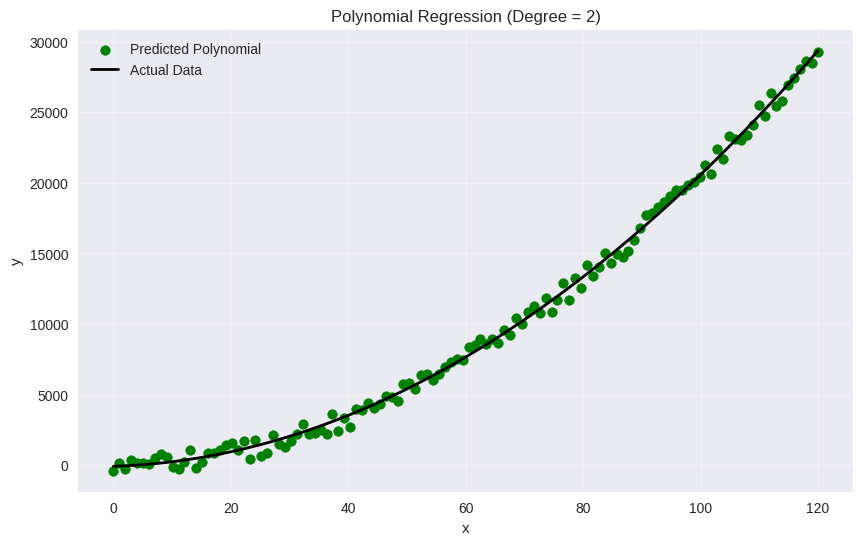

Polynomial Degree: 2
RMSE: 456.631


In [13]:
lin_regression(x,y2)

poly_regression(x,y2,2)

Clearly, polynomial regression does a much better job of modelling the relationship between $x$ and $y$.

# Applying linear regression to housing data

Now that we have an idea of how linear regression works, let's apply it to predicting the price of houses. The dataset being used is the California housing dataset. First, let's take a look at the data.

In [14]:
df = pd.read_csv("https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv")
df['MEDV'] = df['median_house_value']
print("First 5 rows:")
display(df.head())

print("\nDataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

First 5 rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,MEDV
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,342200.0



Dataset Shape: (20640, 11)

Column Names:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity', 'MEDV']


1. MedInc - It is the median income in block group
2. HouseAge - It is the median house age in block group
3. AveRooms - It is the average number of rooms per household
4. AveBedrms - It is the average number of bedrooms per household
5. Population - It is the block group population
6. AveOccup - It is the average number of household members
7. Latitude - It is the block group latitude
8. Longitude - It is the block group longitude
9. MEDV - The target variable is the median house value for California districts, expressed in hundreds of thousands of dollars ($100,000).




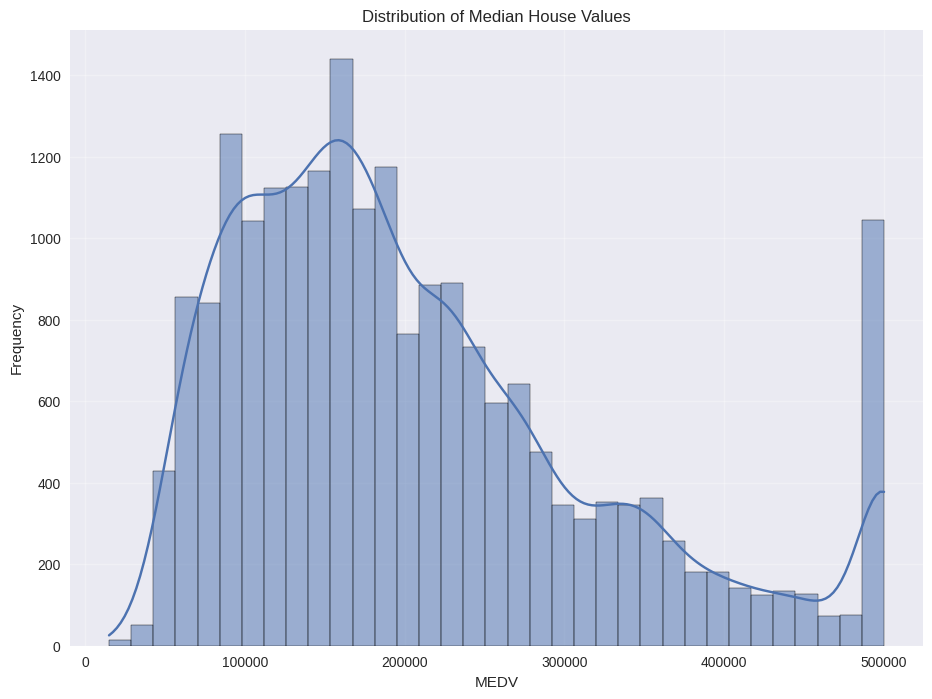

In [15]:
plt.figure(figsize=(11, 8))
sns.histplot(df['MEDV'],bins=35,kde=True)
plt.title("Distribution of Median House Values")
plt.xlabel("MEDV")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
df.drop(['ocean_proximity'],inplace=True,axis=1)

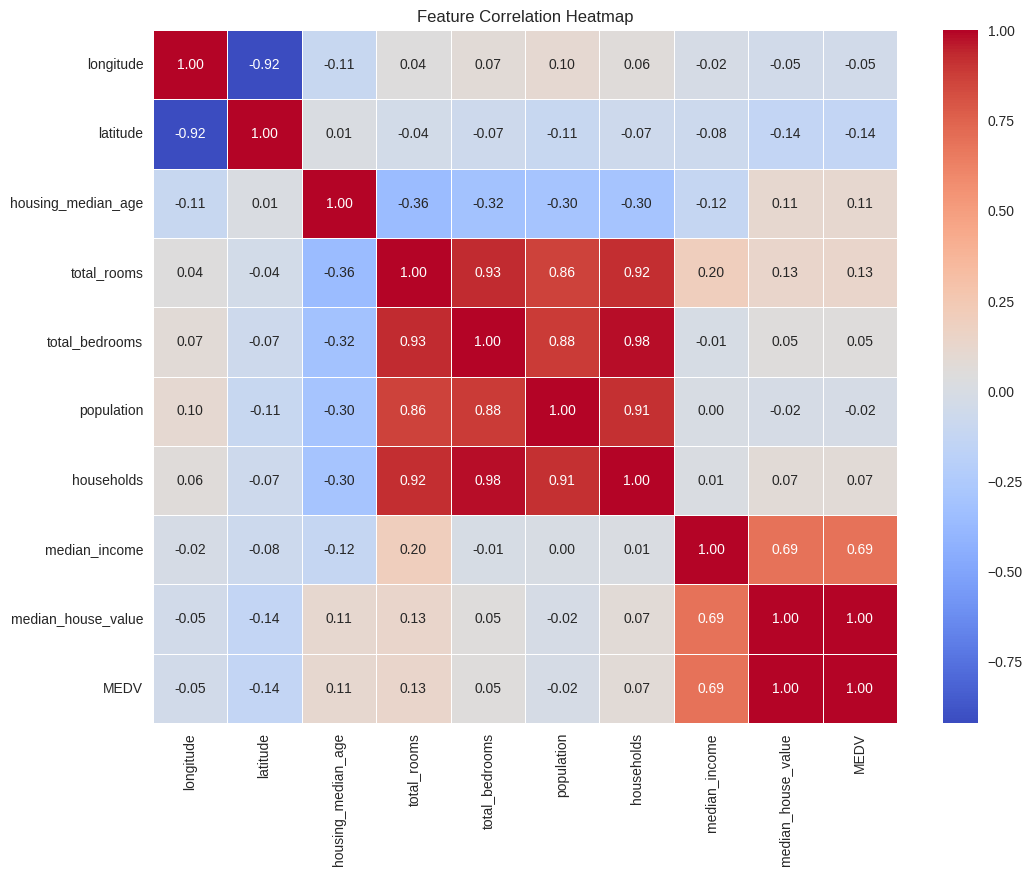

In [19]:
correlation_matrix = df.corr().round(2)
plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)

plt.title("Feature Correlation Heatmap")
plt.show()

The target value MEDV appears to be a normal distribution with some underlying noise. To better understand the linear relationships between the features and the MEDV value, we can use a correlation matrix. This can be neatly visualized with a heatmap

From the plot, we see that MedInc has a high positive correlation with MEDV (0.69). So, we'll pick that as the feature with which we train our regression model.

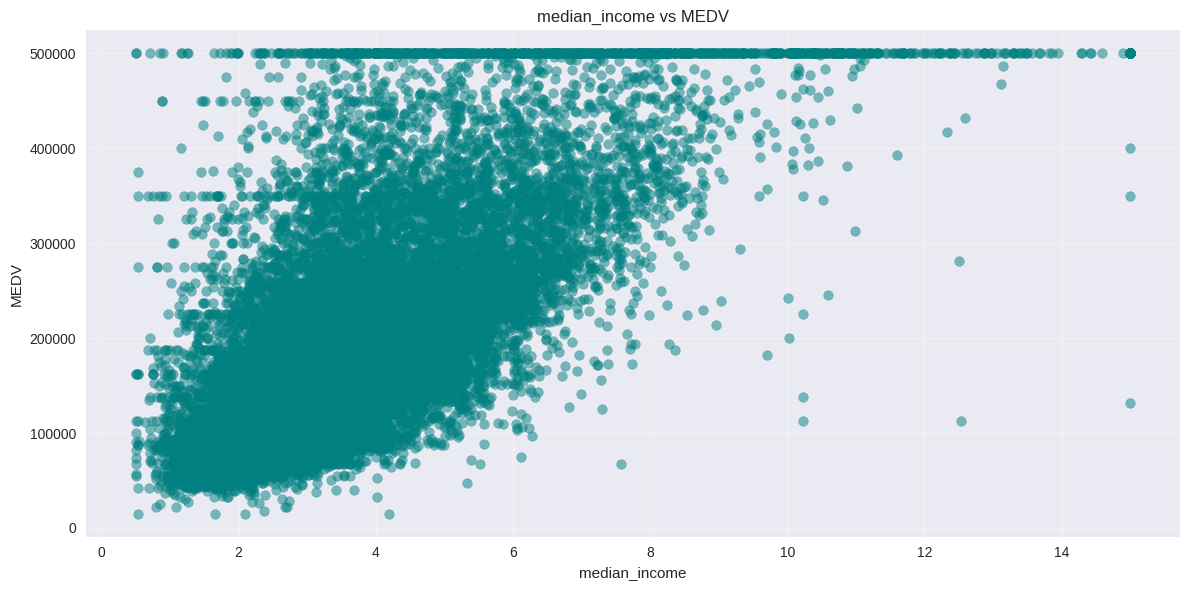

In [20]:
plt.figure(figsize=(12, 6))

features = ['median_income']
target = df['MEDV']

for i, col in enumerate(features):
    plt.subplot(1, len(features) , i+1)
    plt.scatter(df[col],target,alpha=0.5,color='teal')
    plt.title(f'{col} vs MEDV')
    plt.xlabel(col)
    plt.ylabel('MEDV')
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

We can see from the plot that the relationship between MEDV.

In [21]:
x_ex = df[['median_income']]
y_ex = df['MEDV']
x_ex_train, x_ex_test, y_ex_train, y_ex_test = train_test_split(x_ex,y_ex,test_size=0.25,random_state=42)

lin_model = linear_model.LinearRegression()
lin_model.fit(x_ex_train, y_ex_train)
print("Coefficient:", lin_model.coef_[0])
print("Intercept:", lin_model.intercept_)

Coefficient: 41788.08698303917
Intercept: 44967.56419968602


In [22]:
y_ex_train_predict = lin_model.predict(x_ex_train)
train_rmse = np.sqrt(metrics.mean_squared_error(y_ex_train, y_ex_train_predict))

train_r2 = metrics.r2_score(y_ex_train,y_ex_train_predict)

print("Training Set Performance")
print("-" * 30)
print("RMSE :", round(train_rmse, 3))
print("R² Score :", round(train_r2, 3))
y_ex_test_predict = lin_model.predict(x_ex_test)
test_rmse = np.sqrt(metrics.mean_squared_error(y_ex_test, y_ex_test_predict))
test_r2 = metrics.r2_score(y_ex_test,y_ex_test_predict)

print("\nTesting Set Performance")
print("-" * 30)
print("RMSE :", round(test_rmse, 3))
print("R² Score :", round(test_r2, 3))

Training Set Performance
------------------------------
RMSE : 83752.339
R² Score : 0.474

Testing Set Performance
------------------------------
RMSE : 83677.729
R² Score : 0.471


## Exercises

### 1. Higher Degree Polynomials

We have seen a graph of a linear regression model attempting to represent polynomial data, and how it falls short when trying to model non-linear data. Now, what if we took some non-linear noisy data, and fit a very high degree polynomial to it? Try to guess what would happen!

(Change the polynomial degree in the slider and run the cell)

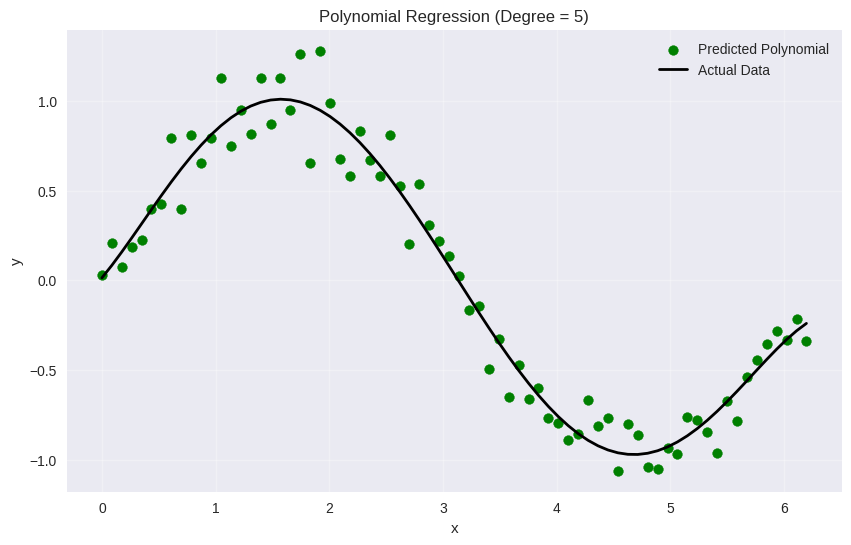

Polynomial Degree: 5
RMSE: 0.135


In [23]:
deg = 5#@param {type:"slider", min: 2, max:15, step:1}

np.random.seed(25)

x_ex = np.array([i*np.pi/180 for i in range(0,360,5)])
y_ex = np.sin(x_ex) + np.random.normal(0,0.12,len(x_ex))
poly_regression(x_ex,y_ex,deg)

The actual data is a noisy sine wave. We can see from the graphs that the higher degree polynomials are too sensitive to the noisy data, they pass through the outliers in data. This is known as **overfitting**. We will explore overfitting in more detail in a later lab.

2. Try running the above with degree set to 1. You will observe that only higher degree polynomials are able to fit to such noisy data.

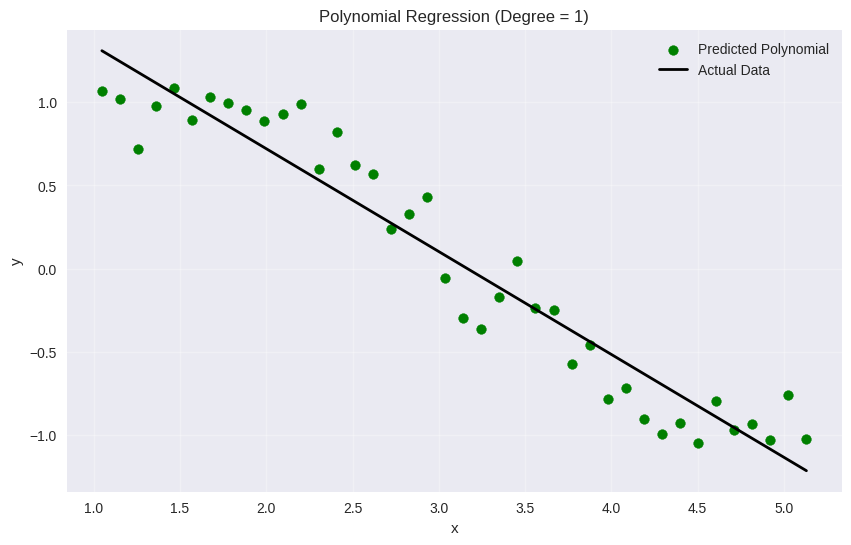

Polynomial Degree: 1
RMSE: 0.215


In [24]:
deg = 1
np.random.seed(10)

x_ex = np.array([i*np.pi/180 for i in range(60,300,6)])
y_ex = np.sin(x_ex) + np.random.normal(0,0.15,len(x_ex))
poly_regression(x_ex,y_ex,deg)

# References

1. https://medium.com/mlearning-ai/implementing-linear-regression-on-california-housing-dataset-378e14e421b7
2. https://towardsdatascience.com/machine-learning-polynomial-regression-with-python-5328e4e8a386
3. https://www.javatpoint.com/linear-regression-in-machine-learning

## Further Explorations

1. [Regression as a closed form solution](https://www.amherst.edu/system/files/media/1287/SLR_Leastsquares.pdf)

2. [Regression as a search](https://mccormickml.com/2014/03/04/gradient-descent-derivation/)

3. [Goodness of fit and R2 score](https://towardsdatascience.com/statistics-for-machine-learning-r-squared-explained-425ddfebf667)